In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('C:/Users/Playdata/Downloads/final_EDA_df.csv')

In [8]:
df.columns

Index(['고객ID', '패션뉴스구독여부', '멤버십상태', '뉴스레터수신빈도', '연령', '구매일', '가격', '상품그룹',
       '연령대', '거래날짜', '이전구매일', '구매간격(일)', 'API ratio', '전체고객이탈여부', '신규고객이탈'],
      dtype='object')

In [9]:
import pandas as pd

# 1. 먼저 '거래날짜' 컬럼을 날짜 형식으로 변환 (가장 중요!)
df['거래날짜'] = pd.to_datetime(df['거래날짜'])

# 2. 날짜 형식인 상태에서 가장 최근 날짜(Maximum) 확인
max_date = df['거래날짜'].max()

# 3. 이제 날짜 객체이므로 1년 전 날짜 계산이 가능합니다.
start_date = max_date - pd.DateOffset(years=1)

# 4. 1년치 데이터만 필터링
filtered_df = df[df['거래날짜'] >= start_date].reset_index(drop=True)

print(f"최근 날짜: {max_date}")
print(f"시작 날짜 (1년 전): {start_date}")
# print(filtered_df)
filtered_df = filtered_df.drop(['API ratio'],axis=1)
filtered_df.info()

# filtered_df.to_csv('C:/Users/Playdata/Downloads/one_year_churn.csv')


최근 날짜: 2020-09-22 00:00:00
시작 날짜 (1년 전): 2019-09-22 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14905795 entries, 0 to 14905794
Data columns (total 14 columns):
 #   Column    Dtype         
---  ------    -----         
 0   고객ID      object        
 1   패션뉴스구독여부  float64       
 2   멤버십상태     object        
 3   뉴스레터수신빈도  object        
 4   연령        float64       
 5   구매일       object        
 6   가격        float64       
 7   상품그룹      object        
 8   연령대       object        
 9   거래날짜      datetime64[ns]
 10  이전구매일     object        
 11  구매간격(일)   float64       
 12  전체고객이탈여부  int64         
 13  신규고객이탈    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(7)
memory usage: 1.6+ GB


In [10]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

cat_cols = ['상품그룹', '멤버십상태', '연령대']
le_dict = {}

# 1. filtered_df가 안전하게 복사본인지 확인 (중요!)
filtered_df = filtered_df.copy()

for col in cat_cols:
    le = LabelEncoder()
    # 2. .loc를 사용하여 명시적으로 해당 컬럼의 모든 행을 변환된 값으로 대입
    # astype(str)은 결측치가 있을 때 에러를 방지하거나 일관성을 위해 유지하는 것이 좋습니다.
    filtered_df.loc[:, col] = le.fit_transform(filtered_df[col].astype(str))
    
    # 역변환을 위해 딕셔너리에 저장
    le_dict[col] = le

# 3. 결과 확인
print(filtered_df[cat_cols].head())
print(filtered_df[cat_cols].dtypes)
filtered_df

  상품그룹 멤버십상태 연령대
0    7     0   3
1    7     0   3
2    7     0   3
3    0     0   3
4    7     0   3
상품그룹     object
멤버십상태    object
연령대      object
dtype: object


,고객ID,패션뉴스구독여부,멤버십상태,뉴스레터수신빈도,연령,구매일,가격,상품그룹,연령대,거래날짜,이전구매일,구매간격(일),전체고객이탈여부,신규고객이탈
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,0,NONE,49.0,2019-09-28,0.054220,7,3,2019-09-28,2019-09-18 00:00:00,10.0,0,0
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,0,NONE,49.0,2019-09-28,0.054220,7,3,2019-09-28,2019-09-28 00:00:00,0.0,0,0
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,0,NONE,49.0,2019-11-22,0.016932,7,3,2019-11-22,2019-09-28 00:00:00,55.0,0,0
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,0,NONE,49.0,2019-11-28,0.018288,0,3,2019-11-28,2019-11-22 00:00:00,6.0,0,0
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,0,NONE,49.0,2019-11-28,0.024407,7,3,2019-11-28,2019-11-28 00:00:00,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14905790,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,0,Regularly,18.0,2020-04-09,0.043203,5,0,2020-04-09,2020-04-05 00:00:00,4.0,0,0
14905791,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,0,Regularly,18.0,2020-04-09,0.013542,7,0,2020-04-09,2020-04-09 00:00:00,0.0,0,0
14905792,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,0,Regularly,18.0,2020-04-25,0.050831,5,0,2020-04-25,2020-04-09 00:00:00,16.0,0,0
14905793,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.0,0,Regularly,18.0,2020-06-22,0.016932,16,0,2020-06-22,2020-04-25 00:00:00,58.0,0,0


In [12]:
mapping_result = {}

for col, le in le_dict.items():
    # 클래스(문자)와 인덱스(숫자)를 매칭하여 딕셔너리 생성
    mapping_result[col] = dict(zip(le.classes_, range(len(le.classes_))))

# 출력해서 확인
import pprint
pprint.pprint(mapping_result)

{'멤버십상태': {'ACTIVE': 0, 'LEFT CLUB': 1, 'PRE-CREATE': 2},
 '상품그룹': {'Accessories': 0,
          'Bags': 1,
          'Cosmetic': 2,
          'Fun': 3,
          'Furniture': 4,
          'Garment Full body': 5,
          'Garment Lower body': 6,
          'Garment Upper body': 7,
          'Garment and Shoe care': 8,
          'Interior textile': 9,
          'Items': 10,
          'Nightwear': 11,
          'Shoes': 12,
          'Socks & Tights': 13,
          'Stationery': 14,
          'Swimwear': 15,
          'Underwear': 16,
          'Underwear/nightwear': 17,
          'Unknown': 18},
 '연령대': {'10대': 0,
         '20대': 1,
         '30대': 2,
         '40대': 3,
         '50대': 4,
         '60대': 5,
         '70대 이상': 6,
         'UNKNOWN': 7}}


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

# 1. 범주형 컬럼 리스트 (가격은 제외)
cat_cols = ['상품그룹', '멤버십상태', '연령대']

# ---------------------------
# 1️⃣ 신규 고객 모델 (LightGBM)
# ---------------------------
X_new = filtered_df[['상품그룹', '멤버십상태', '연령대', '가격','패션뉴스구독여부']].copy()
y_new = filtered_df['신규고객이탈']

# 범주형 컬럼만 타입 변경 (가격은 수치형 그대로 유지)
for col in cat_cols:
    X_new[col] = X_new[col].astype('category')

# 데이터 분할
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    X_new, y_new, test_size=0.2, stratify=y_new, random_state=42
)

Xn_train, Xn_eval, yn_train, yn_eval = train_test_split(Xn_tr, yn_tr) 
eval_set = [(Xn_train,yn_train),(Xn_eval,yn_eval)]


model_new = LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True, # 신규 고객 이탈자 수가 적을 경우 유용
    n_jobs=-1,
    random_state=42
)

# 학습: categorical_feature 명시
model_new.fit(Xn_tr, yn_tr, eval_set = [(Xn_eval, yn_eval)],categorical_feature=cat_cols)

preds_new = model_new.predict_proba(Xn_te)[:, 1]
print(f"신규 고객 모델 AUC: {roc_auc_score(yn_te, preds_new):.4f}")


print(model_new.score(Xn_tr,yn_tr)), print(model_new.score(Xn_te, yn_te))


[LightGBM] [Info] Number of positive: 50758, number of negative: 11873878
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.125122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 280
[LightGBM] [Info] Number of data points in the train set: 11924636, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.004257 -> initscore=-5.455027
[LightGBM] [Info] Start training from score -5.455027
신규 고객 모델 AUC: 0.6084
0.6763587584560233
0.6764976306195006


(None, None)

In [19]:
# 신규 혼동 행렬, 정밀도, 재현율
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
yn_pred = model_new.predict(Xn_te)
print('혼동행렬(Confusion Matrix) \n',confusion_matrix(y_pred=yn_pred, y_true=yn_te),'\n')
print('\n',f'정밀도 : {precision_score(yn_te,yn_pred)}')
print('\n',f'재현율 : {recall_score(yn_te,yn_pred)}')
print('\n',f'정확도 : {accuracy_score(yn_te,yn_pred)}')


혼동행렬(Confusion Matrix) 
 [[2009610  958859]
 [   5553    7137]] 


 정밀도 : 0.007388229350846173

 재현율 : 0.5624113475177305

 정확도 : 0.6764976306195006


In [20]:
# classfication_report 
from sklearn.metrics import classification_report

print(classification_report(yn_te,yn_pred))

              precision    recall  f1-score   support

           0       1.00      0.68      0.81   2968469
           1       0.01      0.56      0.01     12690

    accuracy                           0.68   2981159
   macro avg       0.50      0.62      0.41   2981159
weighted avg       0.99      0.68      0.80   2981159



In [23]:

# ---------------------------
# 2️⃣ 전체 고객 모델 (LightGBM)
# ---------------------------
X_total = filtered_df[['상품그룹', '멤버십상태', '연령대', '가격','패션뉴스구독여부']].copy()
y_total = filtered_df['전체고객이탈여부']

# 동일하게 범주형 컬럼만 타입 변경
for col in cat_cols:
    X_total[col] = X_total[col].astype('category')

# 데이터 분할
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_total, y_total, test_size=0.2, stratify=y_total, random_state=42
)

Xt_train, Xt_eval, yt_train, yt_eval = train_test_split(Xt_tr, yt_tr) 
eval_set = [(Xt_train,yt_train),(Xt_eval,yt_eval)]

model_total = LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=True,
    n_jobs=-1,
    random_state=42
)

# 학습: 전체 고객 모델도 동일하게 카테고리 반영
model_total.fit(Xt_tr, yt_tr, eval_set = [(Xt_eval, yt_eval)],categorical_feature=cat_cols)
preds_total = model_total.predict_proba(Xt_te)[:, 1]
print(f"전체 고객 모델 AUC: {roc_auc_score(yt_te, preds_total):.4f}")
model_new.score(Xt_tr,yt_tr), model_new.score(Xt_te, yt_te)


[LightGBM] [Info] Number of positive: 2093530, number of negative: 9831106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 283
[LightGBM] [Info] Number of data points in the train set: 11924636, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175563 -> initscore=-1.546700
[LightGBM] [Info] Start training from score -1.546700
전체 고객 모델 AUC: 0.6480


(0.579149921221914, 0.5792079523433671)

In [24]:
#  전체고객 혼동 행렬, 정밀도, 재현율
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
y_pred = model_total.predict(Xt_te)
print('혼동행렬(Confusion Matrix) \n',confusion_matrix(y_pred=y_pred, y_true=yt_te),'\n')
print('\n',f'정밀도 : {precision_score(yt_te,y_pred)}')
print('\n',f'재현율 : {recall_score(yt_te,y_pred)}')
print('\n',f'정확도 : {accuracy_score(yt_te,y_pred)}')

cm = confusion_matrix(y_pred=y_pred, y_true=yt_te)

혼동행렬(Confusion Matrix) 
 [[1390706 1067070]
 [ 187378  336005]] 


 정밀도 : 0.23947757603834435

 재현율 : 0.6419868432868473

 정확도 : 0.5792079523433671


In [25]:
# classfication_report 
from sklearn.metrics import classification_report

print(classification_report(yt_te,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.57      0.69   2457776
           1       0.24      0.64      0.35    523383

    accuracy                           0.58   2981159
   macro avg       0.56      0.60      0.52   2981159
weighted avg       0.77      0.58      0.63   2981159



#### 그래프

In [42]:
from sklearn.preprocessing import Binarizer
from sklearn.metrics import accuracy_score

def evaluate_binary_clf(yt_te,y_pred):
    print('혼동행렬')
    print(confusion_matrix(yt_te,y_pred),'\n')
    print(f'정확도 : {accuracy_score(yt_te,y_pred):.4f}/정밀도{precision_score(yt_te,y_pred)}/재현율{recall_score(yt_te,y_pred)}')

pred_proba = model_total.predict_proba(Xt_te)
    

혼동행렬
[[      0 2457776]
 [      0  523383]] 

정확도 : 0.1756/정밀도0.17556359791611248/재현율1.0
혼동행렬
[[      0 2457776]
 [      0  523383]] 

정확도 : 0.1756/정밀도0.17556359791611248/재현율1.0
혼동행렬
[[ 243308 2214468]
 [  15943  507440]] 

정확도 : 0.2518/정밀도0.1864280497357001/재현율0.9695385597163072
혼동행렬
[[1313225 1144551]
 [ 193464  329919]] 

정확도 : 0.5512/정밀도0.22375429815459114/재현율0.6303586474914165
혼동행렬
[[2340634  117142]
 [ 452809   70574]] 

정확도 : 0.8088/정밀도0.3759615589507554/재현율0.13484197996495875
혼동행렬
[[2441666   16110]
 [ 495387   27996]] 

정확도 : 0.8284/정밀도0.634743572303088/재현율0.05349046491766068


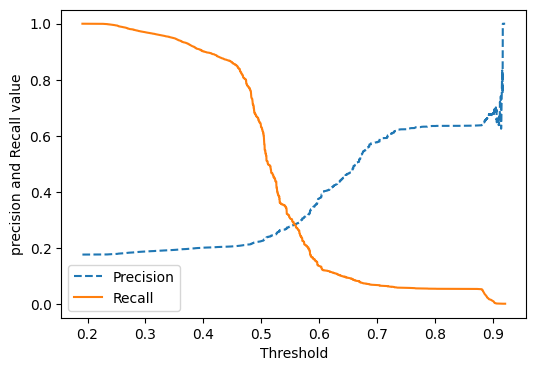

In [43]:

from sklearn.preprocessing import Binarizer
from sklearn.metrics import accuracy_score
pred_proba = model_total.predict_proba(Xt_te)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

thresholds = [0.0, 0.1,0.3,0.5,0.6,0.8]

for threshold in thresholds:
    binarizer = Binarizer(threshold=threshold)
    custom_pred = binarizer.fit_transform(pred_proba_1)
    evaluate_binary_clf(yt_te, custom_pred)

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(yt_te, pred_proba_1) # 정밀도, 재현율은 마지막에 극단적으로 낮은 임계치 값을 적용한 값을 보여줌 ([:-1]) 1개 뺴주기

plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1], linestyle='--', label='Precision')
plt.plot(thresholds, recalls[:-1], label = 'Recall')
plt.xlabel('Threshold')
plt.ylabel('precision and Recall value')
plt.legend()
plt.show()

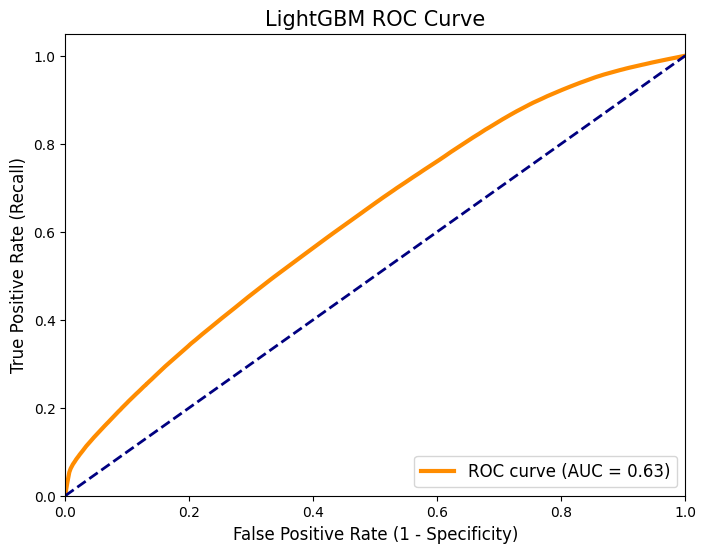

0.6278911505362863

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score


pred_proba = model_total.predict_proba(Xt_te)
pred_proba_1 = pred_proba[:,1].reshape(-1,1)


# fpr, tpr, thresholds = roc_curve(y_test, y_pred)

from sklearn.metrics import auc
fpr, tpr, thresholds = roc_curve(yt_te, pred_proba_1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

# ROC 곡선 그리기 (굵기 조절 및 색상 강조)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 대각선 점선 (Random Guess 기준선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('LightGBM ROC Curve', fontsize=15)
plt.legend(loc="lower right", fontsize=12)

# plt.savefig('./graphs/RF_balanced_ROC_curve.png', dpi=300, bbox_inches='tight')

plt.show()

# roc_auc_score(y_test, pred_proba[:, 1])
roc_auc_score(yt_te, pred_proba_1)


  feature  importance
3      가격        2149
0    상품그룹         474
2     연령대         322
1   멤버십상태          55


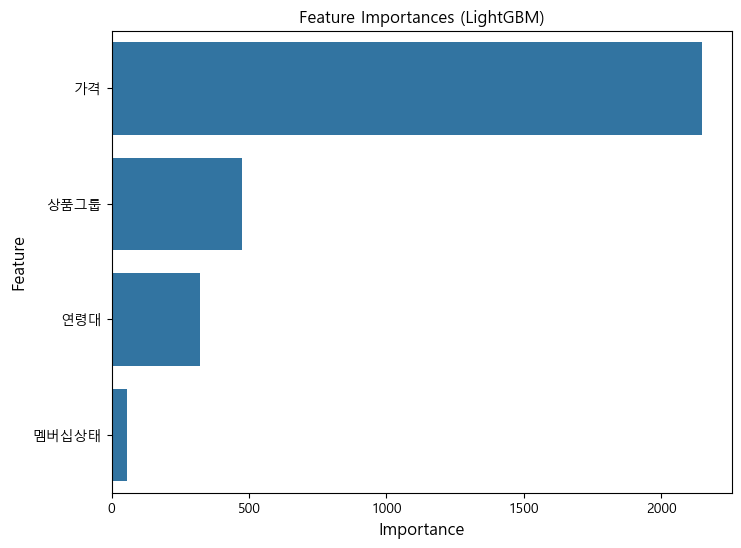

In [46]:
# ==============================
# Feature Importance
# ==============================
importances = model_total.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_new.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

import seaborn as sns
# 한글 설정 (윈도우)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트

plt.figure(figsize=(8,6))
sns.barplot(
    data=feature_importance_df.head(15),
    x='importance',
    y='feature'
)
plt.title('Feature Importances (LightGBM)')
plt.xlabel('Importance',fontsize=12)
plt.ylabel('Feature',fontsize=12)
plt.show()